# MRI Dataset Mode Visualization
This notebook confirms the geometry and metadata for all dataset modes.

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import sys

# Ensure training directory is in path
sys.path.append(os.path.abspath("training"))
from data.datasets.mri_dataset import MRIDataset

DATA_ROOT = "./scratch/nifti/cardiac_1sec_10phase/nifti/card_3.125x3.125x3.125mm_256x256x70x10x4_snr20_fa60_bh"

common_conf = OmegaConf.create(
    {
        "img_size": 518,
        "patch_size": 14,
        "augs": {"scales": [1.0, 1.0], "cojitter": False, "cojitter_ratio": 0.5, "color_jitter": None, "gray_scale": False, "gau_blur": False},
        "rescale": True,
        "rescale_aug": False,
        "landscape_check": False,
        "load_track": False,
        "track_num": 0,
        "training": False,
        "inside_random": False,
        "allow_duplicate_img": False,
        "debug": False,
        "get_nearby": False,
        "load_depth": False,
    }
)

modes = ["static", "dynamic"]
mri_orientations = ["axial", "mixed", "oblique"]
num_slices = 5


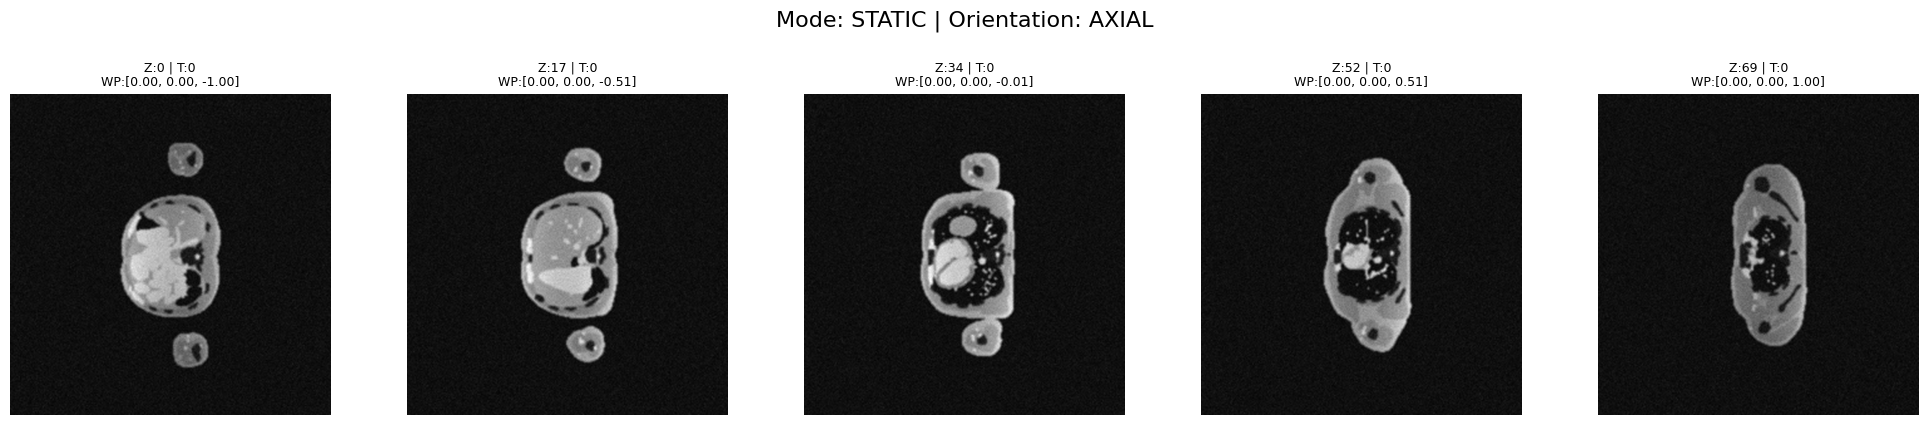

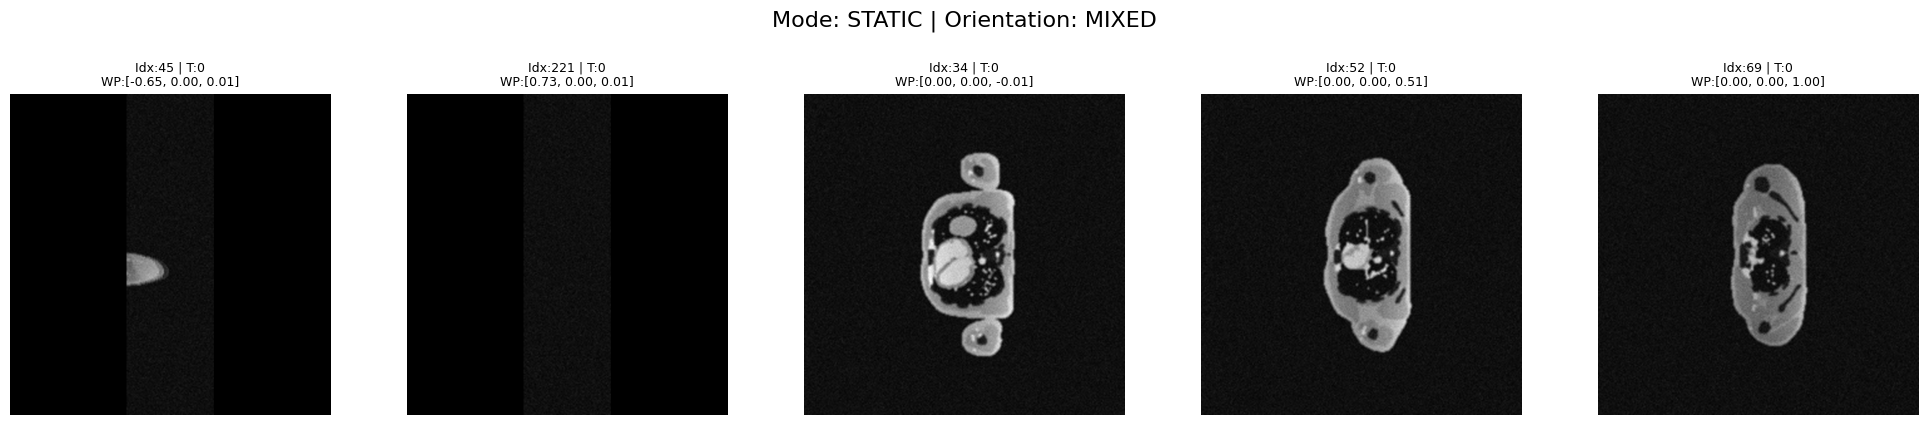

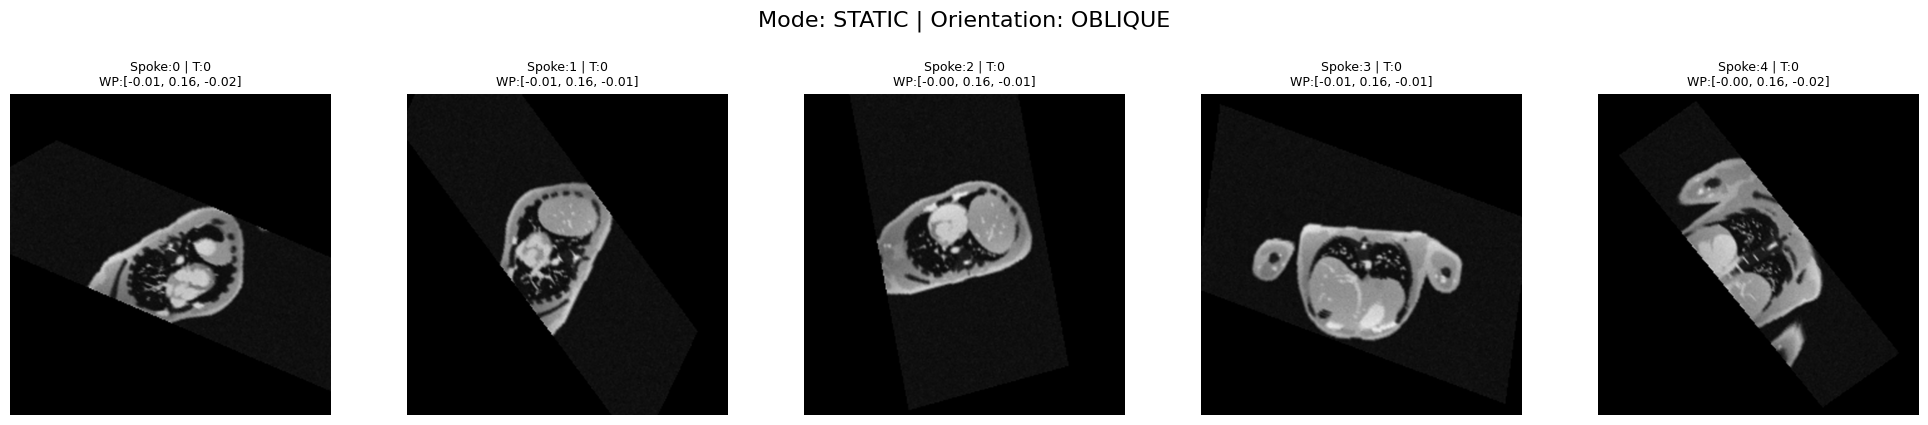

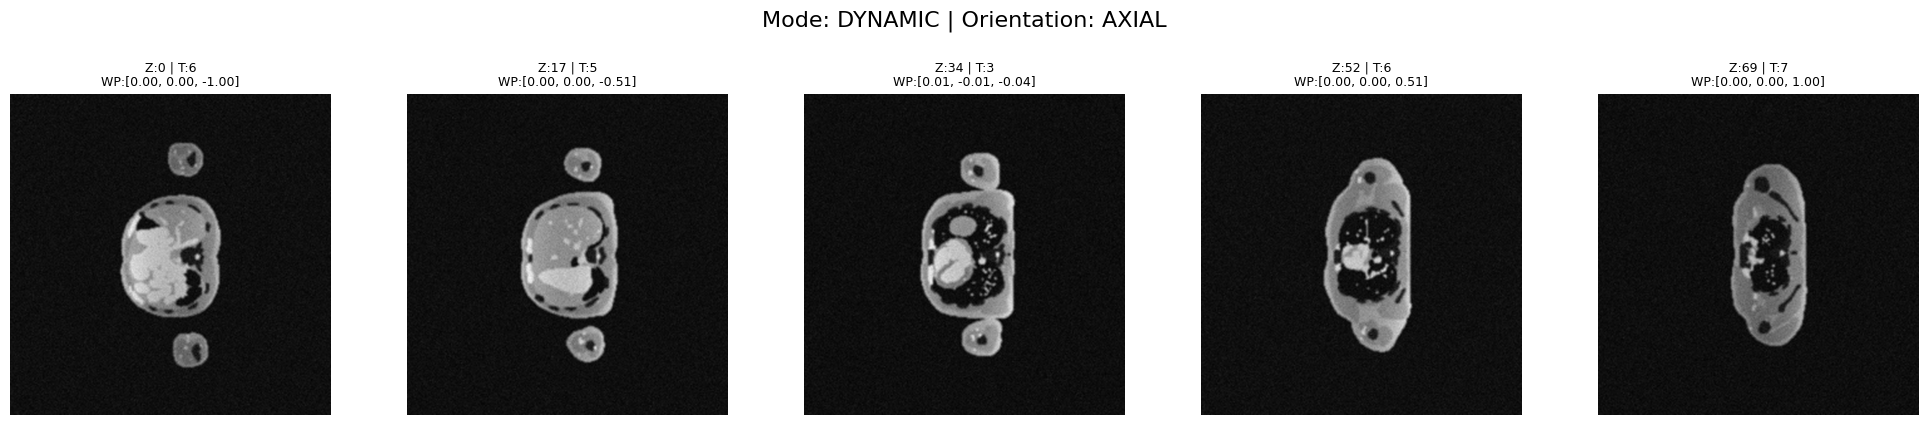

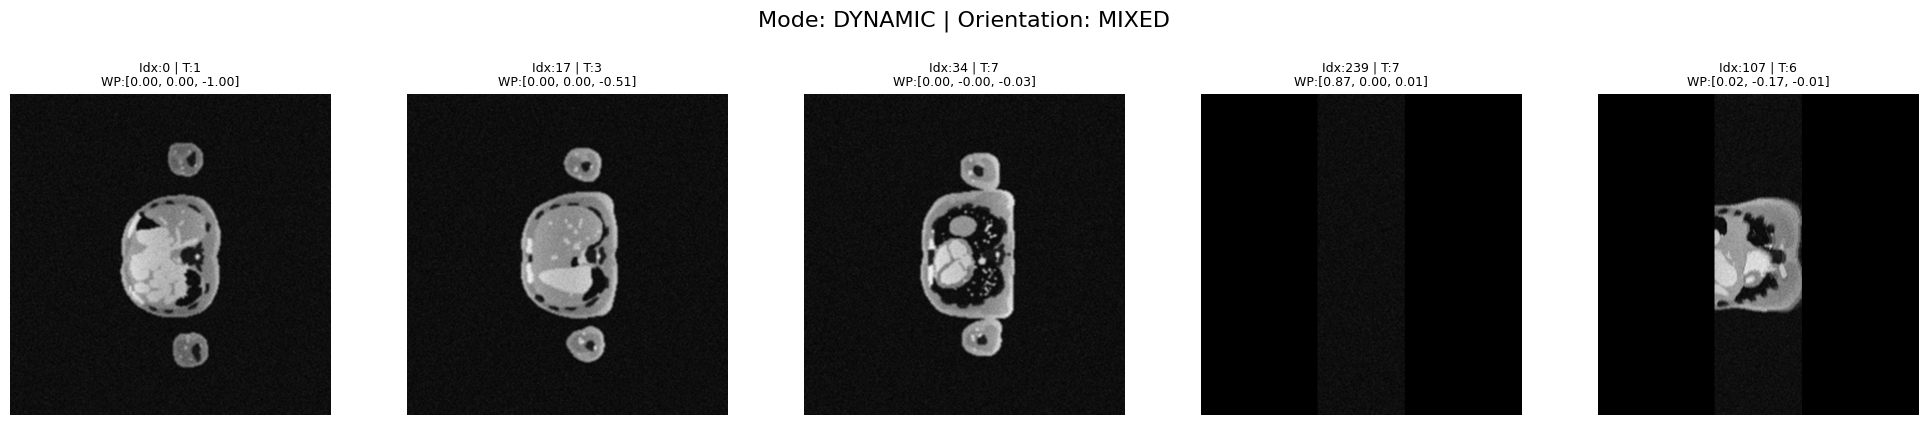

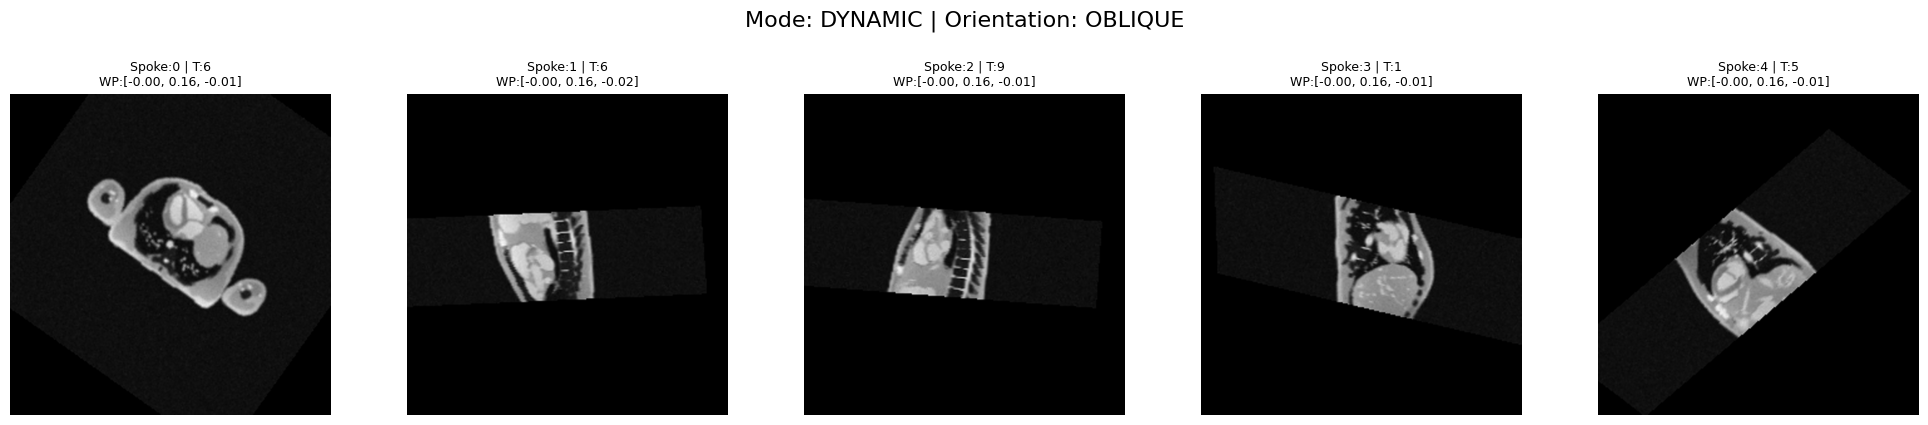

In [10]:
for mode in modes:
    for ori in mri_orientations:
        dataset = MRIDataset(common_conf=common_conf, data_root=DATA_ROOT, mode=mode, mri_mode=ori, num_slices=num_slices)
        data = dataset.get_data(seq_index=0)

        images = data["images"]
        wps = data["world_points"]
        times = data["timesteps"]
        slices = data["slice_indices"]

        fig, axes = plt.subplots(1, num_slices, figsize=(20, 4))

        for i in range(num_slices):
            img = images[i] / 255.0
            ax = axes[i]
            ax.imshow(img)
            center_wp = wps[i][259, 259]

            # Label based on what the SliceIdx actually represents
            label = "Idx"
            if ori == "axial":
                label = "Z"
            elif ori == "oblique":
                label = "Spoke"

            ax.set_title(f"{label}:{slices[i]} | T:{times[i]}\nWP:[{center_wp[0]:.2f}, {center_wp[1]:.2f}, {center_wp[2]:.2f}]", fontsize=9)
            ax.axis("off")

        plt.suptitle(f"Mode: {mode.upper()} | Orientation: {ori.upper()}", fontsize=16, y=1.05)
        plt.tight_layout()
        plt.show()
